In [1]:
# Instalamos librerías adicionales que no vienen por defecto en Colab
!pip install xgboost shap imbalanced-learn --quiet

print('Librerías instaladas correctamente')

Librerías instaladas correctamente


In [117]:
# Modelamiento
import pandas as pd
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, train_test_split,GridSearchCV
from sklearn.impute import SimpleImputer #IMPUTACIÓN
#BALANCEO
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

from sklearn.metrics import accuracy_score, roc_auc_score, recall_score, precision_score, f1_score, roc_curve, auc,classification_report,confusion_matrix,ConfusionMatrixDisplay
#TRANFROMACIONES ANNUMÉRICAS
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from imblearn.over_sampling import SMOTE

# Gráficos
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
ruta = '/content/drive/MyDrive/Churn/Churn_Modelling.csv'
data = pd.read_csv(ruta)

In [5]:
data.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,Num Of Products,Has Credit Card,Is Active Member,Estimated Salary,Churn
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
data.columns = data.columns.str.replace(' ', '_', regex=False)
data.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,Num_Of_Products,Has_Credit_Card,Is_Active_Member,Estimated_Salary,Churn
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
# ELIMINAR DUPLICADOS PORQUE EL MODELO INFLARSE, INFLA LA PRECISIÓN DEL MDELO DEL TARGET 1 O DEL TARGET 0
print(f'No hay datos duplicados: {len(data)==len(data.CustomerId.unique())}')

No hay datos duplicados: True


In [8]:
# Target y variables

#PREDICTORAS

variables= ['CreditScore',
            'Geography',
            'Gender',
            'Age',
            'Tenure',
            'Balance',
            'Num_Of_Products',
            'Has_Credit_Card',
            'Is_Active_Member',
            'Estimated_Salary']

target = 'Churn'

id_cliente = 'CustomerId'



In [9]:
print(type(target),
type(variables),
type(id_cliente))

<class 'str'> <class 'list'> <class 'str'>


In [10]:
# %Missings
#CUANTOS REALMENTE VALORES NULOS PODRIA YO TENER DENTRO DE LAS VARIABLES QUE TOMARE

#RECUERDEN EL ALOGRITOMO VA PROCESAR SI IDENTIFICA VALORES NULOS EN ALGUNO DE LAS VARIABLES


#FUNCIÓN QUE INDIQUE EL % DE VALORES NULOS EN CADA UNO DE TUS VARIABLES
def column_missing_percentage(df):
    missing_values = df.isnull().sum() #CONTABILIZACIÓN DE VALORES NULOS POR CADA VARIABLE
    percentage_missing = (missing_values / len(df)) * 100 # CONVEIRTE EN % ESA CONTABILIZACION
    result_dict = dict(zip(missing_values.index, percentage_missing))
    return result_dict #RETORRNA EL % DENULAS

#LA FUNCIÓN QUE HICE LA APLICO TANTO A LAS VARIABLE SPREDICTORES COMO AL TARGET
column_missing_percentage(data[variables + [target]]) #mi target tambien puede tener tambein nulos


{'CreditScore': 0.0,
 'Geography': 0.0,
 'Gender': 0.0,
 'Age': 0.0,
 'Tenure': 0.0,
 'Balance': 0.0,
 'Num_Of_Products': 0.0,
 'Has_Credit_Card': 0.0,
 'Is_Active_Member': 0.0,
 'Estimated_Salary': 0.0,
 'Churn': 0.0}

ANÁLISIS EXPLORATORIO DE DATOS

In [11]:
# Target
#SACO % DE MI TARGET FRENTE A NO TARGET
print(f'Porcentaje de casos positivos: {np.round(data.Churn.sum()/len(data.Churn)*100,3)}%')


Porcentaje de casos positivos: 20.37%


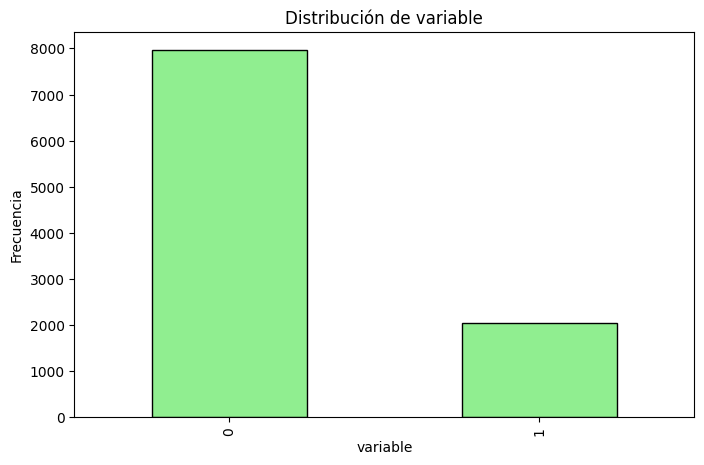

In [12]:
plt.figure(figsize=(8,5))
data[target].value_counts().plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title(f"Distribución de variable")
plt.xlabel("variable")
plt.ylabel("Frecuencia")
plt.show()

In [13]:
#VER LOS TIPOS DE VARIABLES QUE TENGO
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerId        10000 non-null  int64  
 1   Surname           10000 non-null  object 
 2   CreditScore       10000 non-null  int64  
 3   Geography         10000 non-null  object 
 4   Gender            10000 non-null  object 
 5   Age               10000 non-null  int64  
 6   Tenure            10000 non-null  int64  
 7   Balance           10000 non-null  float64
 8   Num_Of_Products   10000 non-null  int64  
 9   Has_Credit_Card   10000 non-null  int64  
 10  Is_Active_Member  10000 non-null  int64  
 11  Estimated_Salary  10000 non-null  float64
 12  Churn             10000 non-null  int64  
dtypes: float64(2), int64(8), object(3)
memory usage: 1015.8+ KB


Debido al que porcentaje de casos positivos es bajo. Antes del entrenamiento debemos balancear los datos

In [14]:
#ME GUSTARIA TENER UNA CLASIFICACIÓN POR EL TIPO DE VARIABLE

# Variables categóricas
data['Geography'] = data['Geography'].str.strip() #ASEGURA QUE Geography SUS VALORES SON DE CADENA


#PONGO EN UNA LISTA TODAS LAS VARIABLES DE TIPO CATEGORICA, PORQUE LES HARE UN TRATAMIENTO DISTINTO POR SER CATEGÓRICAS
categorical_var = ['Geography',
                    'Gender'
                    ]

#PONGO EN LISTA LAS VARIABLES NUMÉRICAS
numerical_var = ['CreditScore',
                 'Age',
                 'Tenure',
                 'Balance',
                 'Num_Of_Products',
                 'Has_Credit_Card',
                 'Is_Active_Member',
                 'Estimated_Salary',
                  ]

In [15]:
#QUIERO VER LOS DATOS DESCRIPTIVOS DE LAS VARIBALES NUMÉRICAS
#SOLAMENTE PARA LAS NUMÉRCIAS
#NO SE PUEDE HACER CON VARIABLES CATEGÓRICOS
data[numerical_var].describe()

#🔴 Balance = 0 — ¿Por qué es sospechoso?
#Imagínate que vas a un banco europeo y tienes 0 euros en tu cuenta. Puede pasar, pero si el 25% de los clientes tiene saldo cero eso es mucho. En un banco real hay dos explicaciones:

# Válido: El cliente usa el banco solo para préstamos o tarjeta, no deposita dinero
# Sospechoso: Son cuentas inactivas que deberían haberse cerrado

# Por eso hay que cruzarlo con Is_Active_Member — si alguien tiene saldo 0 Y es inactivo, probablemente ya se fue pero el sistema aún lo registra.

# 🔴 Age > 80 — ¿Por qué es sospechoso?
# Un cliente de 85 o 92 años con tarjeta de crédito activa y productos bancarios es posible pero inusual. En bases de datos bancarias reales, edades extremas a veces son errores de digitación:

# Alguien escribió 92 cuando era 29
# O 85 cuando era 58

# No los eliminamos automáticamente, pero sí los revisamos.

# 🔴 Estimated_Salary < 1,000 — ¿Por qué es sospechoso?
# Un salario anual de 11.58 euros como muestra el mínimo es prácticamente imposible en Europa. Nadie vive con 11 euros al año. Eso sugiere:

# Error de digitación
# Dato mal registrado
# Cliente sin ingresos formales registrado con un valor mínimo


# 🔴 Num_Of_Products ≥ 3 con Balance = 0 — ¿Por qué es sospechoso?
# Si tienes 3 o 4 productos bancarios (préstamo, cuenta, tarjeta, seguro) pero saldo cero, hay una contradicción lógica:

# ¿Cómo pagas tus productos si no tienes dinero en el banco?
# Puede ser válido si los productos están en mora
# Pero en un banco sano, esa combinación es rara y vale la pena revisarla

,CreditScore,Age,Tenure,Balance,Num_Of_Products,Has_Credit_Card,Is_Active_Member,Estimated_Salary
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000


In [17]:
print('=' * 60)
print('ALERTA 1: BALANCE = 0')
print('=' * 60)
# Cuántos clientes tienen saldo cero en su cuenta
clientes_balance_cero = data[data['Balance'] == 0]
print(f'Cantidad: {clientes_balance_cero.shape[0]}')
print(f'Porcentaje del total: {(data["Balance"]==0).mean()*100:.1f}%')
# Cruzamos con membresía activa para ver si son cuentas fantasma
print('\nDe esos, ¿cuántos son miembros INACTIVOS?')
print(clientes_balance_cero['Is_Active_Member'].value_counts())
print('\nDe esos, ¿cuántos hicieron CHURN?')
print(clientes_balance_cero['Churn'].value_counts())

print('\n' + '=' * 60)
# Cuántos clientes tienen saldo cero en su cuenta
clientes_balance_cero = data[data['Balance'] == 0]
print(f'Cantidad: {clientes_balance_cero.shape[0]}')
print(f'Porcentaje del total: {(data["Balance"]==0).mean()*100:.1f}%')
# Cruzamos con membresía activa para ver si son cuentas fantasma
print('\nDe esos, ¿cuántos son miembros INACTIVOS?')
print(clientes_balance_cero['Is_Active_Member'].value_counts())
print('\nDe esos, ¿cuántos hicieron CHURN?')
print(clientes_balance_cero['Churn'].value_counts())

print('\n' + '=' * 60)
print('ALERTA 2: EDAD EXTREMA (> 80 años)')
print('=' * 60)
# Clientes con edad mayor a 80 — posibles errores de digitación
clientes_edad_extrema = data[data['Age'] > 80]
print(f'Cantidad: {clientes_edad_extrema.shape[0]}')
print(f'Porcentaje del total: {(data["Age"]>80).mean()*100:.2f}%')
print('\nDistribución de edades extremas:')
print(clientes_edad_extrema['Age'].value_counts().sort_index())
print('\nDe esos, ¿cuántos hicieron CHURN?')
print(clientes_edad_extrema['Churn'].value_counts())

print('\n' + '=' * 60)
print('ALERTA 3: SALARIO EXTREMADAMENTE BAJO (< 1,000 euros/año)')
print('=' * 60)
# Salarios casi cero son sospechosos en un banco europeo
clientes_salario_bajo = data[data['Estimated_Salary'] < 1000]
print(f'Cantidad: {clientes_salario_bajo.shape[0]}')
print(f'Porcentaje del total: {(data["Estimated_Salary"]<1000).mean()*100:.2f}%')
print('\nSalarios más bajos encontrados:')
print(clientes_salario_bajo['Estimated_Salary'].sort_values().head(10))

print('\n' + '=' * 60)
print('ALERTA 4: MUCHOS PRODUCTOS CON BALANCE = 0')
print('=' * 60)
# Tener 3 o 4 productos bancarios sin dinero en cuenta es contradictorio
clientes_raros = data[(data['Num_Of_Products'] >= 3) &
                       (data['Balance'] == 0)]
print(f'Cantidad: {clientes_raros.shape[0]}')
print(f'Porcentaje del total: {clientes_raros.shape[0]/len(data)*100:.2f}%')
print('\nDetalle de productos:')
print(clientes_raros['Num_Of_Products'].value_counts())
print('\nDe esos, ¿cuántos hicieron CHURN?')
print(clientes_raros['Churn'].value_counts())

print('\n' + '=' * 60)
print('ALERTA 5: CREDITSCORE EXTREMO (< 400)')
print('=' * 60)
# Score menor a 400 es considerado muy malo en la industria
clientes_score_bajo = data[data['CreditScore'] < 400]
print(f'Cantidad: {clientes_score_bajo.shape[0]}')
print(f'Porcentaje del total: {(data["CreditScore"]<400).mean()*100:.2f}%')
print('\nScores más bajos:')
print(clientes_score_bajo['CreditScore'].sort_values().head(10))

print('\n' + '=' * 60)
print('RESUMEN GENERAL DE ALERTAS')
print('=' * 60)
print(f'Balance = 0:                    {(data["Balance"]==0).sum():>5} clientes')
print(f'Age > 80:                       {(data["Age"]>80).sum():>5} clientes')
print(f'Salary < 1,000:                 {(data["Estimated_Salary"]<1000).sum():>5} clientes')
print(f'Productos >= 3 y Balance = 0:   {clientes_raros.shape[0]:>5} clientes')
print(f'CreditScore < 400:              {(data["CreditScore"]<400).sum():>5} clientes')

ALERTA 1: BALANCE = 0
Cantidad: 3617
Porcentaje del total: 36.2%

De esos, ¿cuántos son miembros INACTIVOS?
Is_Active_Member
1    1873
0    1744
Name: count, dtype: int64

De esos, ¿cuántos hicieron CHURN?
Churn
0    3117
1     500
Name: count, dtype: int64

Cantidad: 3617
Porcentaje del total: 36.2%

De esos, ¿cuántos son miembros INACTIVOS?
Is_Active_Member
1    1873
0    1744
Name: count, dtype: int64

De esos, ¿cuántos hicieron CHURN?
Churn
0    3117
1     500
Name: count, dtype: int64

ALERTA 2: EDAD EXTREMA (> 80 años)
Cantidad: 12
Porcentaje del total: 0.12%

Distribución de edades extremas:
Age
81    4
82    1
83    1
84    2
85    1
88    1
92    2
Name: count, dtype: int64

De esos, ¿cuántos hicieron CHURN?
Churn
0    11
1     1
Name: count, dtype: int64

ALERTA 3: SALARIO EXTREMADAMENTE BAJO (< 1,000 euros/año)
Cantidad: 59
Porcentaje del total: 0.59%

Salarios más bajos encontrados:
2362     11.58
9647     90.07
9010     91.75
5548     96.27
4989    106.67
7565    123.07
24

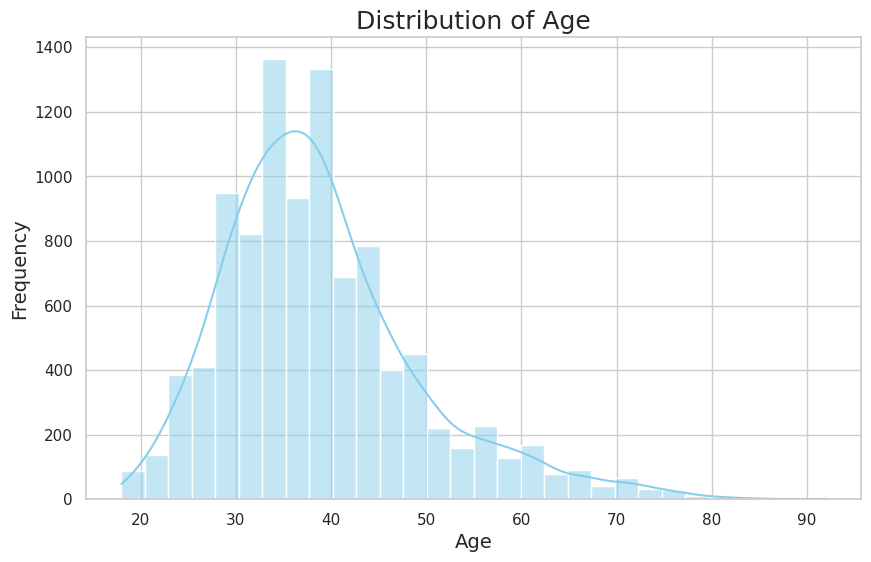

In [18]:
def plot_distribution(data, variable):
    sns.set(style="whitegrid")
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.histplot(data[variable], kde=True, bins=30, color='skyblue')
    ax.set_title(f'Distribution of {variable}', fontsize=18)
    ax.set_xlabel(variable, fontsize=14)
    ax.set_ylabel('Frequency', fontsize=14)
    plt.show()
plot_distribution(data, 'Age') #el min ya está filtrado y el max son pocos casos y además puede darse



#Aunque se identificaron valores extremos, estos representan una proporción pequeña y son plausibles dentro del contexto bancario, por lo que se mantienen para no perder información relevante.”

<Axes: xlabel='Churn', ylabel='Age'>

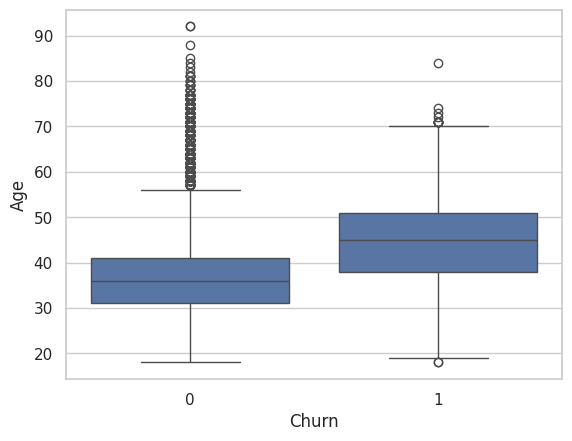

In [33]:
sns.boxplot(x='Churn', y='Age', data=data)

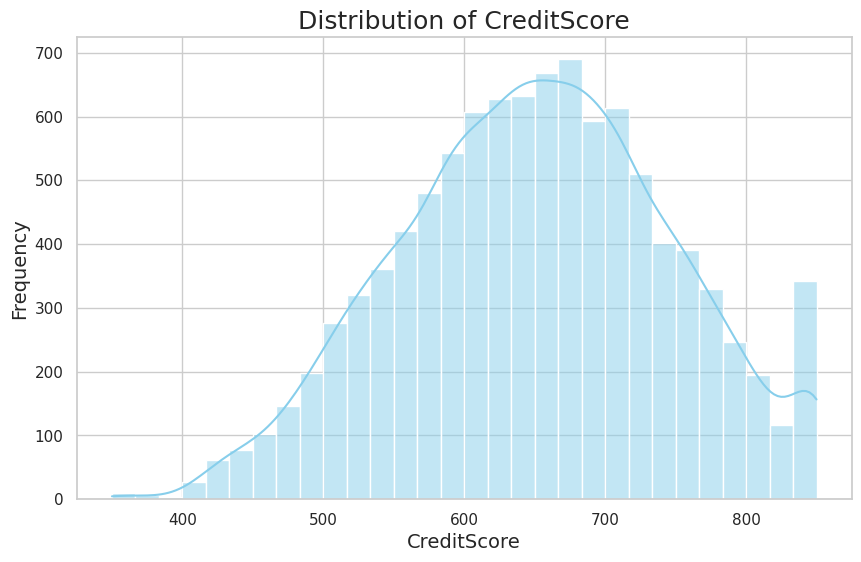

In [19]:
plot_distribution(data, 'CreditScore') #el mpinimo puede darse

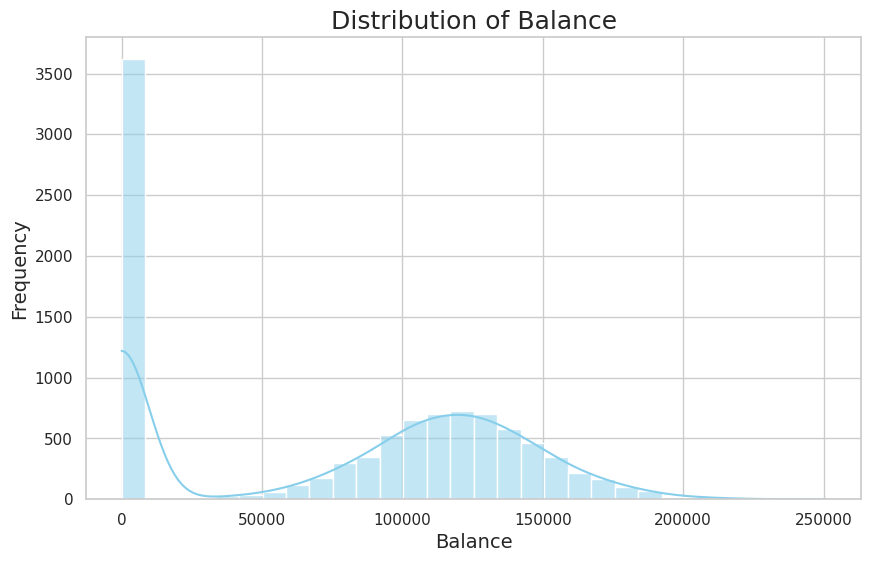

In [20]:
plot_distribution(data, 'Balance') #normal en banca

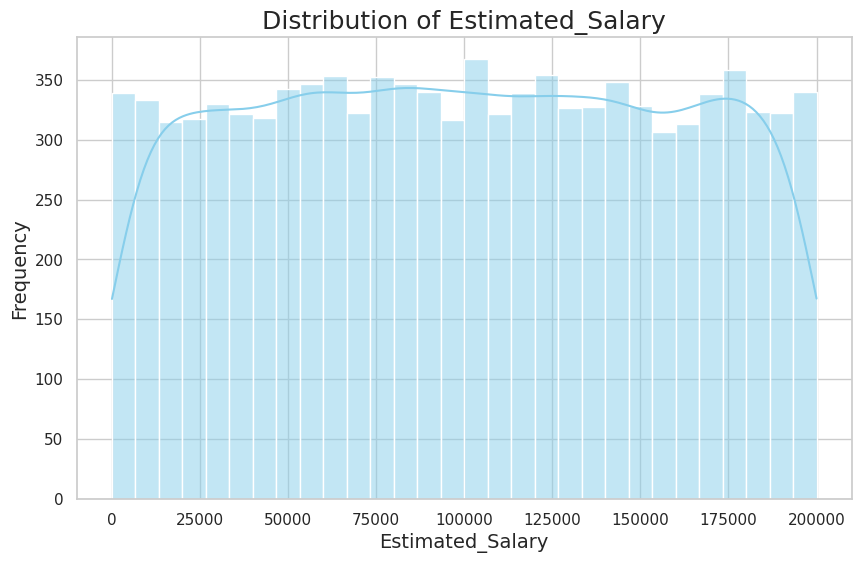

In [23]:
plot_distribution(data, 'Estimated_Salary')

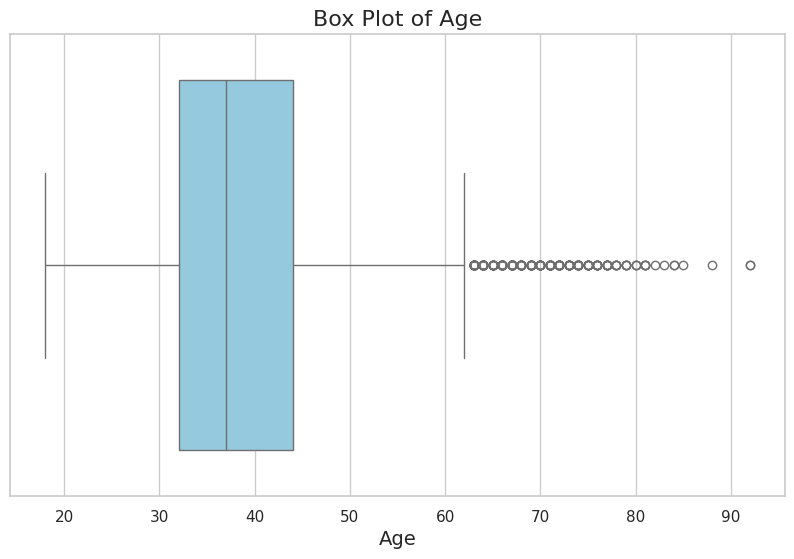

In [28]:
#def plot_box(data, variable):
def plot_box(data, variable):
    sns.set(style="whitegrid")
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.boxplot(x=data[variable], color='skyblue')
    ax.set_title(f'Box Plot of {variable}', fontsize=16)
    ax.set_xlabel(variable, fontsize=14)
    plt.show()
plot_box(data, 'Age')

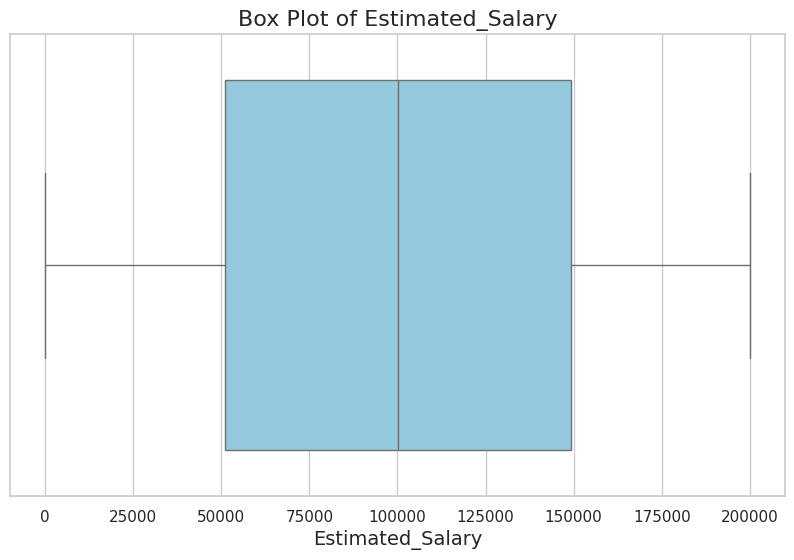

In [29]:
plot_box(data, 'Estimated_Salary')  #NO SE DEBE LIMPIAR

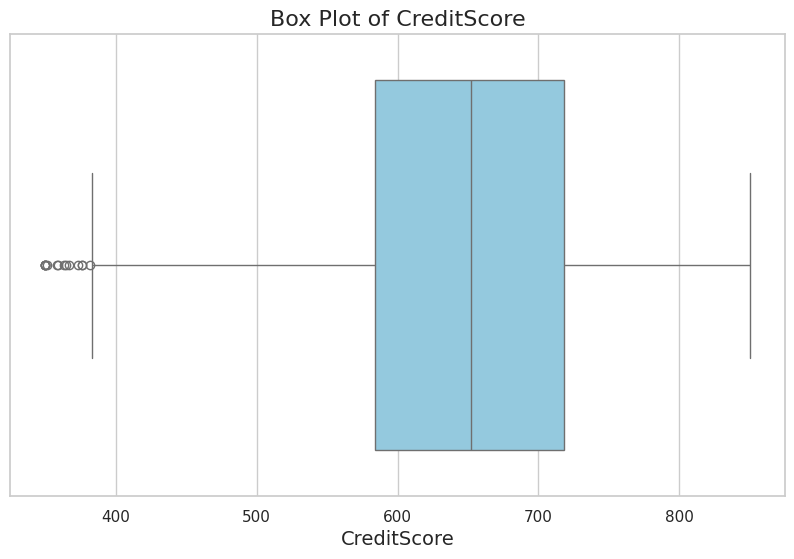

In [32]:
plot_box(data, 'CreditScore')

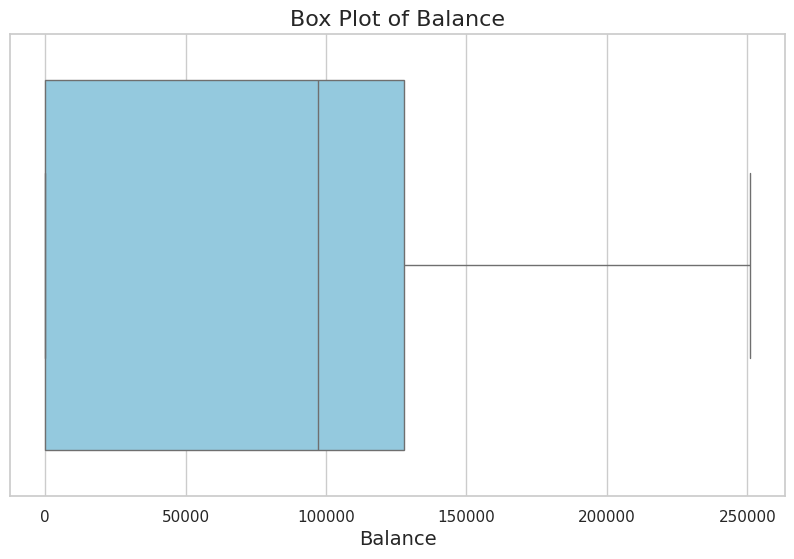

In [34]:
plot_box(data, 'Balance')

<Axes: xlabel='Balance', ylabel='Count'>

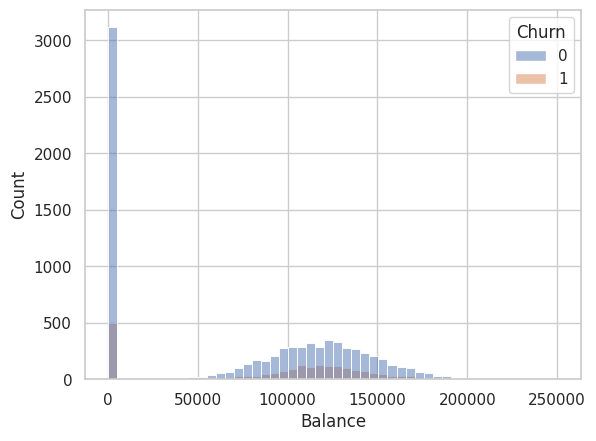

In [35]:
sns.histplot(data=data, x='Balance', hue='Churn', bins=50)
La variable Balance presenta una alta concentración de valores en cero; sin embargo, no se observa una relación directa fuerte con el churn, lo que sugiere que su capacidad predictiva depende de interacciones con otras variables.”

In [36]:
pd.crosstab(
    (data['Balance']==0) & (data['Num_Of_Products']>=3),
    data['Churn'],
    normalize='index'
) #Se identifica un segmento de clientes con múltiples productos y saldo cero que presenta una tasa de churn significativamente superior (≈68%) frente al promedio (≈20%), indicando un alto riesgo de abandono.

Churn,0,1
row_0,,
False,0.801679,0.198321
True,0.321429,0.678571


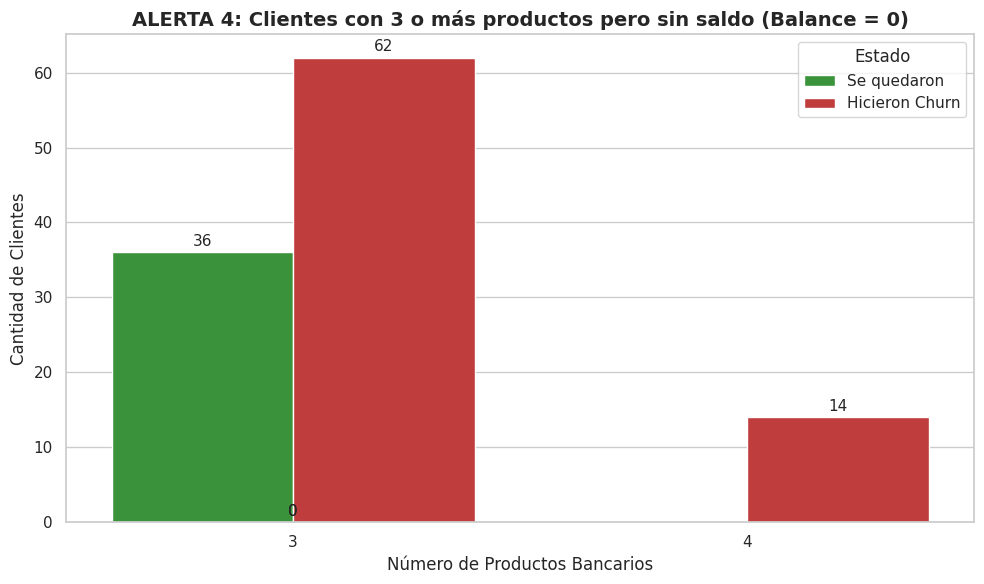

ALERTA 4 - RESUMEN EJECUTIVO
                 Se quedaron  Hicieron Churn  Total  % Churn  % del grupo
Num_Of_Products                                                          
3                         36              62     98     63.3         87.5
4                          0              14     14    100.0         12.5
All                       36              76    112     67.9        100.0

Total de clientes en esta alerta: 112 (1.12% del total del banco)
Tasa de churn general en este grupo: 67.9%


In [42]:
# Filtrado temporal
raros = data[(data['Num_Of_Products'] >= 3) & (data['Balance'] == 0)]


plt.figure(figsize=(10, 6))

sns.countplot(data=raros,
              x='Num_Of_Products',
              hue='Churn',
              palette=['#2ca02c', '#d62728'])

plt.title('ALERTA 4: Clientes con 3 o más productos pero sin saldo (Balance = 0)',
          fontsize=14, fontweight='bold')
plt.xlabel('Número de Productos Bancarios')
plt.ylabel('Cantidad de Clientes')
plt.legend(title='Estado', labels=['Se quedaron', 'Hicieron Churn'])

# Etiquetas sobre las barras
for p in plt.gca().patches:
    plt.gca().annotate(f'{int(p.get_height())}',
                       (p.get_x() + p.get_width()/2., p.get_height() + 0.5),
                       ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

# ====================== TABLA DE PORCENTAJES (CLARA PARA GERENTE) ======================
print("="*60)
print("ALERTA 4 - RESUMEN EJECUTIVO")
print("="*60)

# Tabla principal
tabla = pd.crosstab(raros['Num_Of_Products'], raros['Churn'], margins=True)
tabla.columns = ['Se quedaron', 'Hicieron Churn', 'Total']

# Agregar columna de porcentaje de churn
tabla['% Churn'] = (tabla['Hicieron Churn'] / tabla['Total'] * 100).round(1)
tabla['% del grupo'] = (tabla['Total'] / len(raros) * 100).round(1)

print(tabla)
print(f"\nTotal de clientes en esta alerta: {len(raros)} ({len(raros)/len(data)*100:.2f}% del total del banco)")
print(f"Tasa de churn general en este grupo: {raros['Churn'].mean()*100:.1f}%")

DIVISON DEL DATA SET

In [87]:
X_train, X_test, y_train, y_test = train_test_split (data[variables + [id_cliente]], data[target], test_size=0.3, random_state=42, stratify=data[target])

In [88]:
#FORMO DATASET DONDE DIGO
#EL DATA SET COMPLETO DE TRAIN VA ESTAR DADO POR LA CONCATENACION DE LAS VARIABLES DE TRAIN MAS LA DEPENDIENTE DE TRAIN
D_Train = pd.concat([X_train,y_train], axis=1)

#LO MISMO PARA EL TEST, DATA SET COMPLETO DE TEST O CONSOLIDADO DE TEST
D_Test = pd.concat([X_test,y_test], axis=1)

4 .FEATURE ENGINNERING

In [101]:
#CLASIFICACIÓN PARA TRANSFROMACION DE CCATEGÓRICAS A ETIQUETA
dfTrain = pd.DataFrame()
dfTrain = D_Train.copy()

encoders = {}
for jc in feature_transform:
    enc = LabelEncoder()
    dfTrain['Tran_' + jc] = enc.fit_transform(dfTrain[jc])
    encoders[jc] = enc



In [102]:
dfTrain.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,Num_Of_Products,Has_Credit_Card,Is_Active_Member,Estimated_Salary,CustomerId,Churn,Tran_Geography,Tran_Gender
9136,595,France,Male,20,4,95830.43,1,1,0,177738.98,15688984,0,0,1
6410,689,Spain,Female,63,1,0.00,2,1,1,186526.12,15762351,0,2,0
2607,814,France,Male,31,1,118870.92,1,1,0,101704.19,15814209,0,0,1
3201,722,France,Male,20,6,0.00,2,1,0,195486.28,15637593,0,0,1
3330,738,France,Male,18,4,0.00,2,1,1,47799.15,15657439,0,0,1


In [103]:
# Variable nueva basada en hallazgo del EDA
# Clientes con muchos productos pero sin saldo — alto riesgo de churn
dfTrain['TRA_riesgo_productos'] = (
    (dfTrain['Num_Of_Products'] >= 3) &
    (dfTrain['Balance'] == 0)
).astype(int)

dfTrain.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,Num_Of_Products,Has_Credit_Card,Is_Active_Member,Estimated_Salary,CustomerId,Churn,Tran_Geography,Tran_Gender,TRA_riesgo_productos
9136,595,France,Male,20,4,95830.43,1,1,0,177738.98,15688984,0,0,1,0
6410,689,Spain,Female,63,1,0.00,2,1,1,186526.12,15762351,0,2,0,0
2607,814,France,Male,31,1,118870.92,1,1,0,101704.19,15814209,0,0,1,0
3201,722,France,Male,20,6,0.00,2,1,0,195486.28,15637593,0,0,1,0
3330,738,France,Male,18,4,0.00,2,1,1,47799.15,15657439,0,0,1,0


In [104]:
var_final = ['CreditScore',
             'Age',
             'Tenure',
             'Balance',
             'Num_Of_Products',
             'Has_Credit_Card',
             'Is_Active_Member',
             'Estimated_Salary',
             'Tran_Geography',
             'Tran_Gender',
             'TRA_riesgo_productos']

<Axes: >

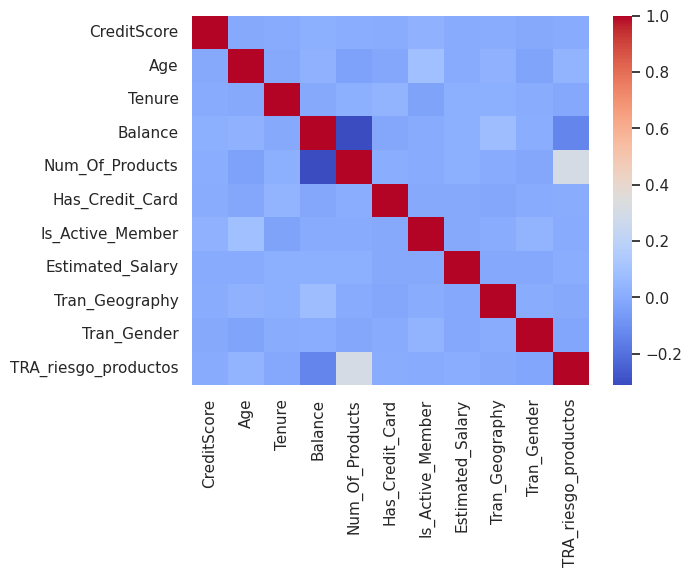

In [105]:
corr = np.corrcoef(dfTrain[var_final].values.T)
sns.heatmap(corr, xticklabels=var_final, yticklabels=var_final, cmap='coolwarm')

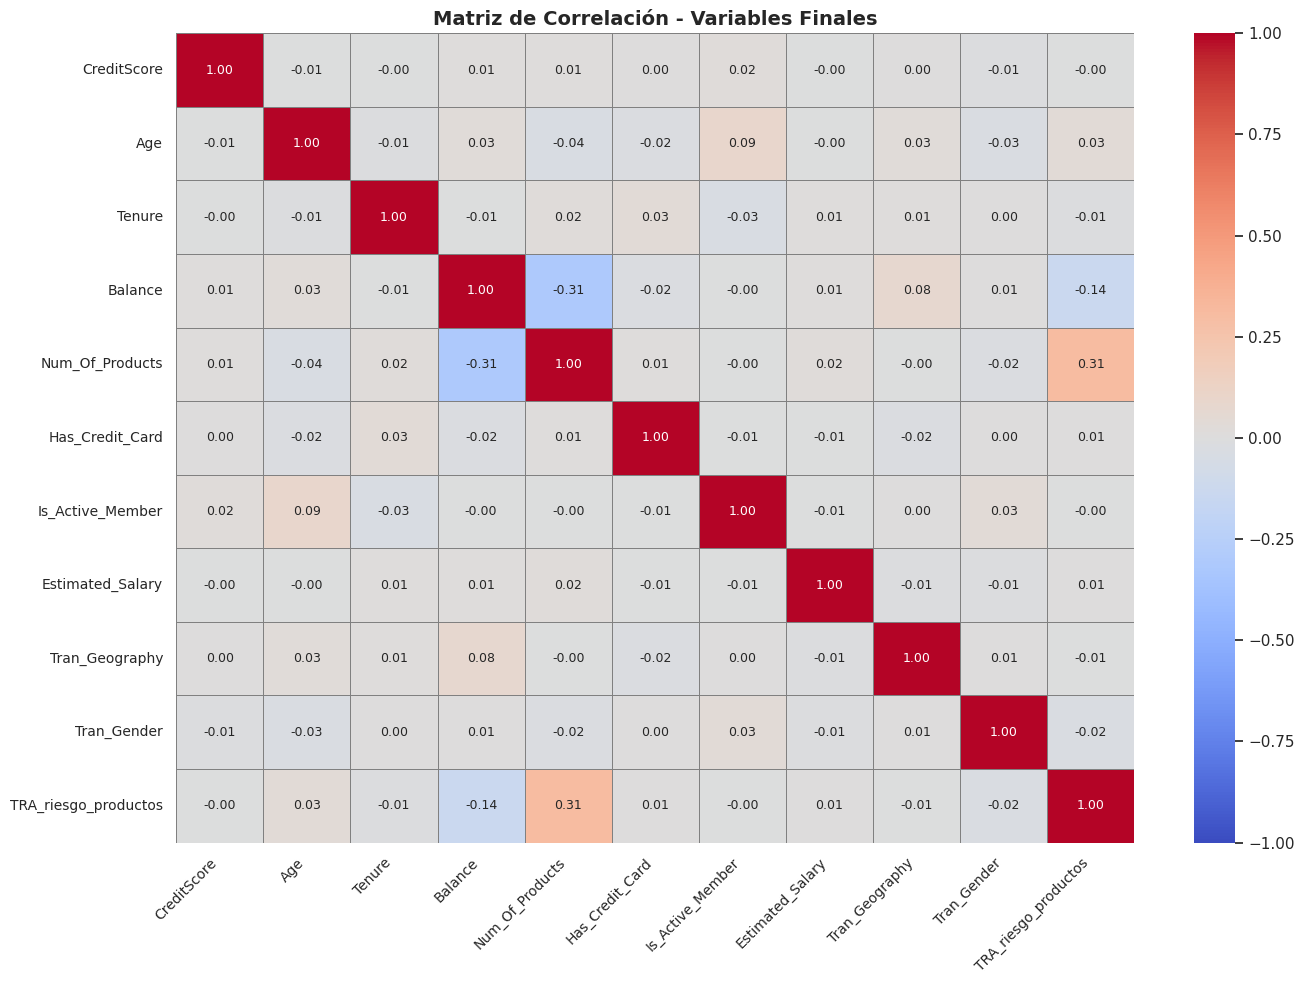

In [106]:
corr = np.corrcoef(dfTrain[var_final].values.T)

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    xticklabels=var_final,
    yticklabels=var_final,
    cmap='coolwarm',
    annot=True,        # muestra los números dentro
    fmt='.2f',         # 2 decimales
    vmin=-1, vmax=1,   # escala fija
    linewidths=0.5,
    linecolor='gray',
    annot_kws={"size": 9}
)

plt.title('Matriz de Correlación - Variables Finales', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()


MODEL TRAINING

In [107]:
# BALANCEOOOOOOOOOOOOOOOOOOOOOOOOO
# Realizamos un SMOOT:
smote = SMOTE(sampling_strategy=0.5, random_state=42)
#NUEVO DATA SET
X_smote, y_smote = smote.fit_resample(dfTrain[var_final], dfTrain['Churn'])

#NUEVO DATA SET DE VARIABLES PREDICTORAS Y DE TARGET PQ YA ESTA BALANCEADO
X_train_resampled = X_smote.copy()
y_train_resampled = y_smote.copy()

In [108]:
#CUANDO HACEMOS BALANCEO HAY QUE RESETEAR EL INDX PARA QUE SALGA COMO DATAFRMAE

X_train_resampled=X_train_resampled.reset_index(drop=True)
y_train_resampled=y_train_resampled.reset_index(drop=True)

In [109]:
X_train_resampled.head() #YA ESTA BALANCEADO

,CreditScore,Age,Tenure,Balance,Num_Of_Products,Has_Credit_Card,Is_Active_Member,Estimated_Salary,Tran_Geography,Tran_Gender,TRA_riesgo_productos
0,595,20,4,95830.43,1,1,0,177738.98,0,1,0
1,689,63,1,0.00,2,1,1,186526.12,2,0,0
2,814,31,1,118870.92,1,1,0,101704.19,0,1,0
3,722,20,6,0.00,2,1,0,195486.28,0,1,0
4,738,18,4,0.00,2,1,1,47799.15,0,1,0


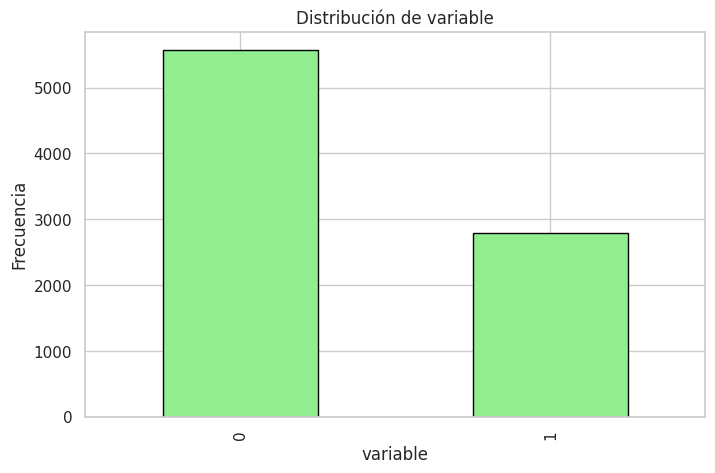

In [110]:
plt.figure(figsize=(8,5))
y_train_resampled.value_counts().plot(kind='bar', color='lightgreen', edgecolor='black')
plt.title(f"Distribución de variable")
plt.xlabel("variable")
plt.ylabel("Frecuencia")
plt.show()

In [ ]:
#APLICIACIÓN A LA BASE TEST

In [111]:
dfTest['TRA_riesgo_productos'] = (
    (D_Test['Num_Of_Products'] >= 3) &
    (D_Test['Balance'] == 0)
).astype(int)

In [112]:
dfTest = pd.DataFrame()
dfTest = D_Test.copy()

for jc in feature_transform:
    dfTest['Tran_' + jc] = encoders[jc].transform(dfTest[jc])

dfTest['TRA_riesgo_productos'] = (
    (dfTest['Num_Of_Products'] >= 3) &
    (dfTest['Balance'] == 0)
).astype(int)

print("TRAIN:", dfTrain[var_final].shape)
print("TEST: ", dfTest[var_final].shape)

TRAIN: (7000, 11)
TEST:  (3000, 11)


In [113]:
#VARIABLES DE TEST

y_test = dfTest[target].astype(int)
x_test_transform =dfTest[var_final].astype(float)

In [114]:
x_test_transform.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3000 entries, 6417 to 9704
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   CreditScore           3000 non-null   float64
 1   Age                   3000 non-null   float64
 2   Tenure                3000 non-null   float64
 3   Balance               3000 non-null   float64
 4   Num_Of_Products       3000 non-null   float64
 5   Has_Credit_Card       3000 non-null   float64
 6   Is_Active_Member      3000 non-null   float64
 7   Estimated_Salary      3000 non-null   float64
 8   Tran_Geography        3000 non-null   float64
 9   Tran_Gender           3000 non-null   float64
 10  TRA_riesgo_productos  3000 non-null   float64
dtypes: float64(11)
memory usage: 281.2 KB


XGBOOST

In [118]:
# =============================
# XGBOOST
# =============================

xgb = xgb.XGBClassifier(        #HIPERPARÁMETOS
      n_estimators=20,         # número de árboles
      learning_rate=0.1,        # CORRECION DE 0.1
      max_depth=3,              # profundidad máxima
      subsample=0.9,            # submuestreo de filas DE 0.9 PARA QUE SEA MAS RAPIDO
      reg_alpha=0.1,            # regularización L1
      reg_lambda=1.0,           # regularización L2
      random_state=42,
)

#ENTRENAMIENTO

#Generamos la ecuación con la data de train

xgb.fit(X_train_resampled, y_train_resampled)

#Generamos la predicción para el dataset de train

y1_pred_xgb = xgb.predict(X_train_resampled)

#predicción usando base test
y_pred_xgb = xgb.predict(x_test_transform)

In [119]:
# =============================
# Evaluación
# =============================
acc_xgb_train = accuracy_score(y_train_resampled, y1_pred_xgb)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

print("🚀 Accuracy XGBoost TRAIN (XGBOOST):", round(acc_xgb_train, 4))
print("🚀 Accuracy XGBoost TEST (XGBOOST):", round(acc_xgb, 4))

#REPORTE
print("\n--- Reporte XGBoost TEST ---")
print(classification_report(y_test, y_pred_xgb))


#Accuracy alto pero puede ser engañoso por posible sesgo a parte no target
#recall menor a 0.65, pobre
#f1 score de 0.58 pobre
#precision aceptable

🚀 Accuracy XGBoost TRAIN (XGBOOST): 0.8067
🚀 Accuracy XGBoost TEST (XGBOOST): 0.852

--- Reporte XGBoost TEST ---
              precision    recall  f1-score   support

           0       0.88      0.94      0.91      2389
           1       0.68      0.51      0.58       611

    accuracy                           0.85      3000
   macro avg       0.78      0.72      0.75      3000
weighted avg       0.84      0.85      0.84      3000



In [120]:
# Define un umbral de probabilidad
def evaluate_model(y_test,y_hat,y_hat_prob):
    ROC_AUC=roc_auc_score(y_test,y_hat)
    PRECISION = precision_score(y_test, y_hat, average='binary')
    RECALL=recall_score(y_test, y_hat, average='binary')
    ACCURACY=accuracy_score(y_test, y_hat)
    F1_SCORE=score = f1_score(y_test, y_hat, average='binary')
    print({'ROC AUC': ROC_AUC, 'PRECISION': PRECISION,'RECALL':RECALL,'ACCURACY':ACCURACY,'F1_SCORE':F1_SCORE})

#EL UMBRAL ES EL y_hat

In [123]:
# Evaluar test
#-------------
y = y_test
y_prob = xgb.predict_proba(x_test_transform)[:, 1]
y_hat =(y_prob >= 0.5).astype(int) #AJUSTE DEL UMBRAL DE LA MATRIZ DE CONFUSION

print('1. Test:')
print(evaluate_model(y,y_hat ,y_prob))

y_tr_r = y_train_resampled
y_prob_tr_r = xgb.predict_proba(X_train_resampled)[:, 1]
y_hat_tr_r =(y_prob_tr_r >= 0.5).astype(int)

print('2. Train Resampled:')
print(evaluate_model(y_tr_r,y_hat_tr_r ,y_prob_tr_r))

#Curva ROC de 0.72 aceptable mayor a 0.65

1. Test:
{'ROC AUC': np.float64(0.7237536472059953), 'PRECISION': 0.6843267108167771, 'RECALL': 0.5073649754500819, 'ACCURACY': 0.852, 'F1_SCORE': 0.5827067669172933}
None
2. Train Resampled:
{'ROC AUC': np.float64(0.7395048439181916), 'PRECISION': 0.8204707170224411, 'RECALL': 0.5378543236454969, 'ACCURACY': 0.8067216840090898, 'F1_SCORE': 0.6497615951452103}
None


RANDOM FOREST

In [125]:
# =============================
#  Bagging: Random Forest
# =============================

rf = RandomForestClassifier(
    n_estimators=100,     # número de árboles
    criterion="gini",
    max_depth=3,
    random_state=42
)

rf.fit(X_train_resampled, y_train_resampled)

y1_pred_rf = rf.predict(X_train_resampled)

y_pred_rf = rf.predict(x_test_transform)


In [128]:
# Evaluar test
y = y_test
y_prob = rf.predict_proba(x_test_transform)[:, 1]
y_hat =(y_prob >= 0.5).astype(int)

print('1. Test:')
print(evaluate_model(y,y_hat ,y_prob))

y_tr_r = y_train_resampled
y_prob_tr_r = rf.predict_proba(X_train_resampled)[:, 1]
y_hat_tr_r =(y_prob_tr_r >= 0.5).astype(int)

print('2. Train Resampled:')
print(evaluate_model(y_tr_r,y_hat_tr_r ,y_prob_tr_r))

#Recall recontra pobre
#F1 pobre más pobre que XGBOOST
#Precisi´pn aceptable de 0.698

#Curva ROC-AUC menor a XGBOOST

1. Test:
{'ROC AUC': np.float64(0.6717781786269448), 'PRECISION': 0.6982248520710059, 'RECALL': 0.3862520458265139, 'ACCURACY': 0.841, 'F1_SCORE': 0.49736564805057953}
None
2. Train Resampled:
{'ROC AUC': np.float64(0.7076605669178327), 'PRECISION': 0.8494983277591973, 'RECALL': 0.4556871187656979, 'ACCURACY': 0.7916517163018778, 'F1_SCORE': 0.5931807566557683}
None


EVALUACIÓN DEL MODELO SELECCIONADO

In [ ]:
#Me quedo con el XGBOOST porque me genera mejores indicadores, el indicador
#de desempate que elegi fueron el recall, f1 y curva ROC-auc, el recall porque se enfoca
#más en las predicciones target que el mmodelo predice y en realidad si son target
# y en el f1 porque es una ponderación del recall con la precisión
#además también el ROC- AUC porque me genera mayor área bajo la curva (aleatoriedad), lo que me indica
#que de los 2 modelos xgb y rf, el xgb es el que mejor gestiona a la parte de los mejores probables
# y llega más rapido a la precisión comparado al rf.


In [129]:
# El modelo Seleccionado es XGBOOST
modelFin = xgb

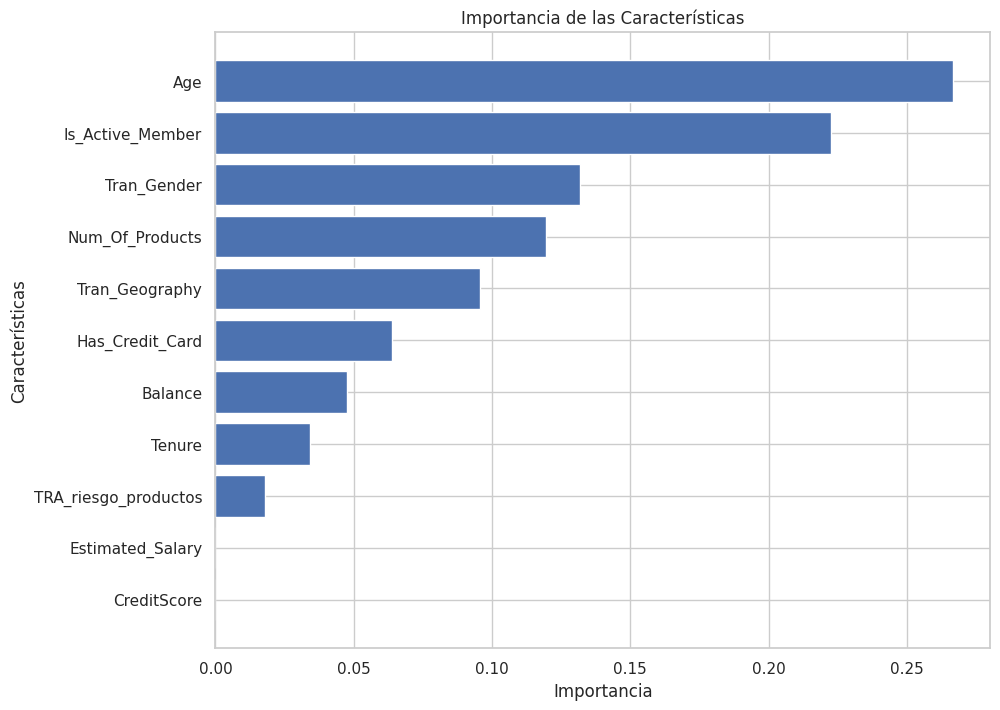

In [130]:
feature_importance = modelFin.feature_importances_
feature_names = X_train_resampled.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importance})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importancia')
plt.ylabel('Características')
plt.title('Importancia de las Características')
plt.show()

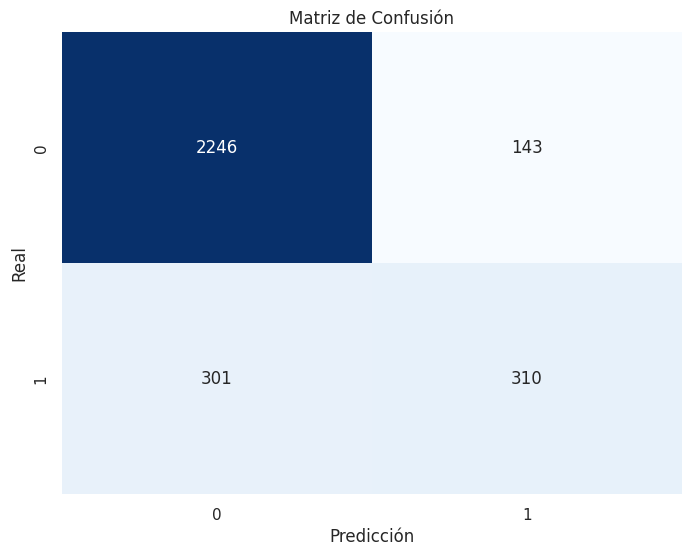

In [132]:
# Matriz de confusión
y_pred = modelFin.predict_proba(x_test_transform)[:, 1] >= 0.5

confusion = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()


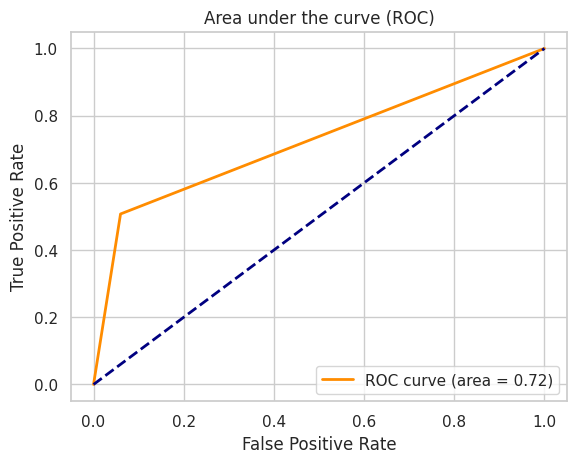

In [133]:
# Curva de ROC
fpr, tpr, _ = roc_curve(y_test, y_pred )
roc_auc = auc(fpr, tpr)
# Grafica la curva ROC y el área bajo la curva
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Area under the curve (ROC)')
plt.legend(loc='lower right')
plt.show()

In [141]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [142]:
# Modelo base
xgb_opt = XGBClassifier(random_state=42)

In [149]:
param_dist= {     #HIPERPARÁMETOS
      'n_estimators': [100, 200],        # número de árboles
      'learning_rate':[0.1, 0.3],        # CORRECION DE 0.1
      'max_depth': [3, 4, ],              # profundidad máxima
      'subsample':[0.9, 0.15],            # submuestreo de filas DE 0.9 PARA QUE SEA MAS RAPIDO
      'reg_alpha':[0.1, 0.6],            # regularización L1
      'reg_lambda':[1.0, 2]
              }# regularización L2




In [150]:
# Validación cruzada estratificada
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

In [151]:
# Configurar búsqueda aleatoria:

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=3,             # Número de combinaciones aleatorias a probar
    scoring='roc_auc',     # Métrica de evaluación
    n_jobs=-1,             # Usa todos los núcleos
    cv=cv,
    random_state=42,
    verbose=1
)

In [152]:
# Entrenar la búsqueda
random_search.fit(X_train_resampled, y_train_resampled)

Fitting 3 folds for each of 3 candidates, totalling 9 fits


RandomizedSearchCV(cv=StratifiedKFold(n_splits=3, random_state=42, shuffle=True),
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=False,
                                           eval_metric=None, feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow...
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None, n_estimators=20,
                                           n_jobs=None, num_parallel_tree=None, ...),
                   n_iter=3, n_jobs=-1,
                   param_distributions={'learning_rate': [0.1, 0.3],
                                        'max_depth': [3, 4],
                                        'n_estimators': [100, 200],
                                        'reg_alpha': [0.1, 0.6],
                                        'reg_lambda': [1.0, 2],
                                        'subsample': [0.9, 0.15]},
                   random_state=42, scoring='roc_auc', verbose=1)

In [153]:
print("\n🔹 Mejor combinación de hiperparámetros:")
print(random_search.best_params_)

print("\n🔹 Mejor AUC promedio (validación cruzada):")
print(random_search.best_score_)


🔹 Mejor combinación de hiperparámetros:
{'subsample': 0.9, 'reg_lambda': 1.0, 'reg_alpha': 0.6, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.3}

🔹 Mejor AUC promedio (validación cruzada):
0.8895349892608424
